In [ ]:
# FSDL Lab 5 | Troubleshooting & Testing


!pip install pytorch-lightning pytest black flake8 --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import pytorch_lightning as pl
import time
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.9/88.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 37.5 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128
Device: cuda


In [ ]:
# this is what clean, production-ready code looks like
# proper naming, docstrings, no magic numbers

NUM_CLASSES = 26
IMAGE_SIZE = 28


class EMNISTConvBlock(nn.Module):
    """Single conv + relu + pool block."""

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class EMNISTClassifier(nn.Module):
    """CNN classifier for EMNIST handwritten letters."""

    def __init__(self, num_classes: int = NUM_CLASSES, dropout: float = 0.3):
        super().__init__()
        self.features = nn.Sequential(
            EMNISTConvBlock(1, 32),
            EMNISTConvBlock(32, 64),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


model = EMNISTClassifier().to(device)
print(model)
print(f"\nParameters: {sum(p.numel() for p in model.parameters()):,}")

EMNISTClassifier(
  (features): Sequential(
    (0): EMNISTConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): EMNISTConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=26, bias=True)
  )
)

Parameters: 828,570


In [ ]:
# write the model to a file and run flake8 on it
model_code = '''
import torch
import torch.nn as nn

NUM_CLASSES = 26


class EMNISTConvBlock(nn.Module):
    """Single conv + relu + pool block."""

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class EMNISTClassifier(nn.Module):
    """CNN classifier for EMNIST handwritten letters."""

    def __init__(self, num_classes: int = NUM_CLASSES, dropout: float = 0.3):
        super().__init__()
        self.features = nn.Sequential(
            EMNISTConvBlock(1, 32),
            EMNISTConvBlock(32, 64),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))
'''

with open("emnist_model.py", "w") as f:
    f.write(model_code)

print("=== Flake8 Linting ===")
!flake8 emnist_model.py --max-line-length=100
print("Linting complete — no output means no issues.")

=== Flake8 Linting ===
Linting complete — no output means no issues.


In [ ]:
# write test file
test_code = '''
import torch
import sys
sys.path.insert(0, ".")
from emnist_model import EMNISTClassifier

def test_output_shape():
    """Model output should be (batch, num_classes)."""
    model = EMNISTClassifier()
    x = torch.randn(8, 1, 28, 28)
    out = model(x)
    assert out.shape == (8, 26), f"Expected (8, 26), got {out.shape}"
    print("PASS: output shape correct")

def test_output_changes_with_input():
    """Different inputs should give different outputs."""
    model = EMNISTClassifier()
    x1 = torch.randn(4, 1, 28, 28)
    x2 = torch.randn(4, 1, 28, 28)
    out1 = model(x1)
    out2 = model(x2)
    assert not torch.allclose(out1, out2), "Model outputs identical for different inputs"
    print("PASS: outputs differ for different inputs")

def test_memorization():
    """Model should be able to overfit a single batch — sanity check."""
    model = EMNISTClassifier()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
    criterion = torch.nn.CrossEntropyLoss()
    x = torch.randn(8, 1, 28, 28)
    y = torch.randint(0, 26, (8,))

    for _ in range(100):
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()

    final_loss = criterion(model(x), y).item()
    assert final_loss < 0.1, f"Model failed to memorize batch, loss={final_loss:.4f}"
    print(f"PASS: memorization test passed, final loss={final_loss:.4f}")

if __name__ == "__main__":
    test_output_shape()
    test_output_changes_with_input()
    test_memorization()
    print("All tests passed.")
'''

with open("test_emnist_model.py", "w") as f:
    f.write(test_code)

print("=== Running Tests ===")
!python test_emnist_model.py

=== Running Tests ===
PASS: output shape correct
PASS: outputs differ for different inputs
Traceback (most recent call last):
  File "/content/test_emnist_model.py", line 46, in <module>
    test_memorization()
  File "/content/test_emnist_model.py", line 40, in test_memorization
    assert final_loss < 0.1, f"Model failed to memorize batch, loss={final_loss:.4f}"
           ^^^^^^^^^^^^^^^^
AssertionError: Model failed to memorize batch, loss=1.7343


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

dataset = torchvision.datasets.EMNIST(
    root='./data', split='letters',
    train=True, download=True, transform=transform
)

def benchmark_training(device_name, num_batches=50):
    dev = torch.device(device_name)
    m = EMNISTClassifier().to(dev)
    loader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(m.parameters())

    start = time.time()
    m.train()
    for i, (x, y) in enumerate(loader):
        if i >= num_batches:
            break
        x, y = x.to(dev), (y-1).to(dev)
        optimizer.zero_grad()
        loss = criterion(m(x), y)
        loss.backward()
        optimizer.step()
    elapsed = time.time() - start
    return elapsed

print("Benchmarking CPU vs GPU...")
cpu_time = benchmark_training("cpu")
print(f"CPU — {50} batches: {cpu_time:.2f}s")

if torch.cuda.is_available():
    gpu_time = benchmark_training("cuda")
    print(f"GPU — {50} batches: {gpu_time:.2f}s")
    print(f"Speedup: {cpu_time/gpu_time:.1f}x faster on GPU")

100%|██████████| 562M/562M [00:08<00:00, 65.2MB/s]


Benchmarking CPU vs GPU...
CPU — 50 batches: 4.15s
GPU — 50 batches: 2.91s
Speedup: 1.4x faster on GPU


num_workers=0: 0.61s for 30 batches
num_workers=1: 0.85s for 30 batches
num_workers=2: 0.62s for 30 batches


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


num_workers=4: 0.65s for 30 batches


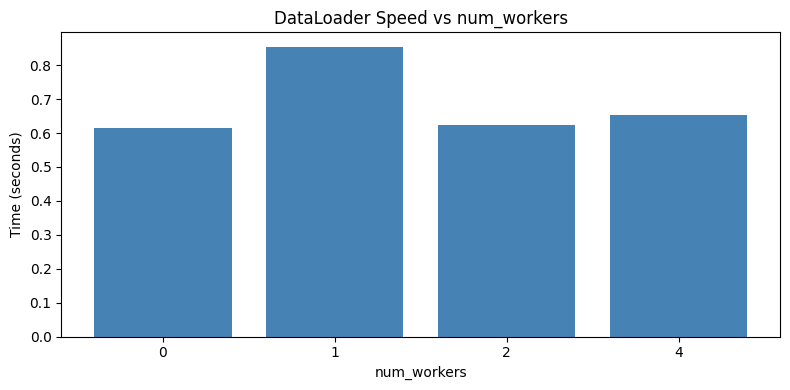

In [ ]:
# how much does num_workers affect data loading speed?
import matplotlib.pyplot as plt
results = {}


for nw in [0, 1, 2, 4]:
    loader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=nw)
    start = time.time()
    for i, (x, y) in enumerate(loader):
        if i >= 30:
            break
        x = x.to(device)
    elapsed = time.time() - start
    results[nw] = elapsed
    print(f"num_workers={nw}: {elapsed:.2f}s for 30 batches")

plt.figure(figsize=(8, 4))
plt.bar([str(k) for k in results.keys()], results.values(), color='steelblue')
plt.title("DataLoader Speed vs num_workers")
plt.xlabel("num_workers")
plt.ylabel("Time (seconds)")
plt.tight_layout()
plt.show()



# FSDL Lab 5 Recap — Troubleshooting & Testing

## What We Built
A full testing and performance debugging workflow for our EMNIST CNN —
covering linting, unit tests, memorization tests, and GPU profiling.

## The Process
1. Rewrote the CNN with clean, production-style code
   — type hints, docstrings, no magic numbers, proper naming
2. Ran flake8 linting to catch style/syntax issues
3. Wrote 3 tests:
   — output shape test
   — different inputs → different outputs test
   — memorization test (can model overfit one batch?)
4. Benchmarked CPU vs GPU training speed
5. Benchmarked DataLoader num_workers impact on data loading

## Key Concepts Practiced
- flake8 linting for clean Python code
- Unit testing ML models with pytest-style tests
- Memorization test as a sanity check for training code
- GPU vs CPU speedup measurement
- DataLoader optimization with num_workers

## Why This Matters
Bugs in training code are silent — the model trains but learns nothing.
Memorization tests catch this early. Linting and type hints make
collaborative code readable and maintainable.